<a href="https://colab.research.google.com/github/maleatencio/PetFinder/blob/main/eda_PETFINDER_MY_Lab_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GRUPO 2**

**Atencio, Malena Renée | Tec. en Cs. de Datos | MU 0004**

**Orellana, Luz Maria | Tec. en Cs. de Datos | MU 00030**

**Santellan, Andrea Paola | Tec. en Cs. de Datos | MU 0018**

## 1. INTRODUCCION
## Analisis exploratorio de datos "PETFINDER.MY"

Utilizando el DataSet PetFinder.my, de la comunidad de cientificos de datos "KAGGLE", propuesto por la Prof. Lic. Cintia Sosa Chasampi para la catedra Laboratorio de Datos de la Carrera Tecnicatura en Cs. de Datos perteneciente a la Facultad de Cs. Aplicadas y Naturales de la UNCa.

Este Dataset PetFinder.my "Buscador de mascotas", proviene del sitio web de adopción de mascotas de Malasia, donde refugios y particulares publican mascotas en adopción.

El Data set contiene datos de las mascotas en adopción, con características físicas, médicas, ubicación, fotos y texto, contiene datos mixtos y muy variados como: Datos tabulares, numéricos y categóricos e información estructurada sobre cada mascota.

El objetivo es predecir la velocidad de adopción de una mascota segun el conjuto de datos brindados en este dataset.


In [ ]:
from google.colab import drive
import pandas as pd

# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargar archivo CSV
dataset = pd.read_csv('/content/drive/MyDrive/PETFINDER/train.csv')

# Mostrar primeras filas
dataset.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


## 2. DICCIONARIO DE DATOS
**PetFinder.my**

| Variable      | Tipo de dato | Descripción                                                                                      |
| ------------- | ------------ | ------------------------------------------------------------------------------------------------ |
| Type          | Entero       | Tipo de mascota (1 = Perro, 2 = Gato)                                                            |
| Name          | Texto        | Nombre de la mascota                                                                             |
| Age           | Entero       | Edad en meses                                                                                    |
| Breed1        | Entero       | Raza principal (código)                                                                          |
| Breed2        | Entero       | Raza secundaria (0 = ninguna)                                                                    |
| Gender        | Entero       | Sexo (1 = Macho, 2 = Hembra, 3 = Mixto)                                                          |
| Color1        | Entero       | Color principal (código)                                                                         |
| Color2        | Entero       | Color secundario                                                                                 |
| Color3        | Entero       | Tercer color                                                                                     |
| MaturitySize  | Entero       | Tamaño estimado adulto (1 = Pequeño, 2 = Mediano, 3 = Grande, 4 = Extra grande, 0 = Desconocido) |
| FurLength     | Entero       | Largo del pelaje (1 = Corto, 2 = Medio, 3 = Largo, 0 = Desconocido)                              |
| Vaccinated    | Entero       | Vacunado (1 = Sí, 2 = No, 3 = No seguro)                                                         |
| Dewormed      | Entero       | Desparasitado (1 = Sí, 2 = No, 3 = No seguro)                                                    |
| Sterilized    | Entero       | Esterilizado/Castrado (1 = Sí, 2 = No, 3 = No seguro)                                            |
| Health        | Entero       | Estado de salud (1 = Saludable, 2 = Lesión menor, 3 = Lesión grave, 0 = Desconocido)             |
| Quantity      | Entero       | Cantidad de mascotas en la publicación                                                           |
| Fee           | Entero       | Costo de adopción                                                                                |
| State         | Entero       | Estado/región de Malasia (código)                                                                |
| RescuerID     | Texto        | ID del rescatista/publicador                                                                     |
| VideoAmt      | Entero       | Cantidad de videos                                                                               |
| Description   | Texto        | Descripción de la mascota                                                                        |
| PetID         | Texto        | ID único de la mascota                                                                           |
| PhotoAmt      | Decimal      | Cantidad de fotos                                                                                |
| AdoptionSpeed | Entero       | Variable objetivo: velocidad de adopción                                                         |

## Variable objetivo a estudiar:

| Valor | Significado                     |
| ----- | ------------------------------- |
| 0     | Adoptado el mismo día           |
| 1     | Adoptado entre 1 y 7 días       |
| 2     | Adoptado entre 8 y 30 días      |
| 3     | Adoptado entre 31 y 90 días     |
| 4     | No adoptado después de 100 días |


In [ ]:
#Informacion de Variables

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

## 3. ANALISIS GENERAL DE LAS VARIABLES
El conjunto de datos analizado contiene 14.993 registros y 24 variables, correspondientes a información sobre mascotas publicadas para adopción en la plataforma PetFinder.my

Las variables presentan distintos tipos de datos: numéricos enteros, numéricos decimales y texto.

##Clasificación por tipo de dato
Variables enteras (int64): 19
Corresponden principalmente a variables categóricas codificadas numéricamente y variables cuantitativas discretas como edad, cantidad de mascotas y costo de adopción.
Variables decimales (float64): 1
La variable PhotoAmt, que representa la cantidad de fotografías disponibles en cada publicación.
Variables de texto (object): 4
Incluyen nombre de la mascota, identificadores únicos y descripción textual.
Variables con valores faltantes

**Se observan valores nulos solo en dos variables:**

Name: 13.728 valores no nulos → faltan 1.265 registros.
Description: 14.980 valores no nulos → faltan 13 registros.


##Distribución funcional de las variables
**Variables descriptivas de la mascota**

Type, Name, Age, Breed1, Breed2, Gender, Color1, Color2, Color3, MaturitySize, FurLength

Describen características físicas y generales del animal.

**Variables sanitarias y de cuidado**

Vaccinated, Dewormed, Sterilized, Health

Indican condiciones de salud y tratamientos recibidos.

**Variables de publicación**

Quantity, Fee, VideoAmt, PhotoAmt, Description

Relacionadas con la forma en que la mascota fue publicada.

**Variables identificadoras**

RescuerID, PetID

Sirven para identificar al rescatista y a cada mascota.

**Variable geográfica**

State

Representa la región o estado de procedencia.

**Variable objetivo**

AdoptionSpeed

Indica la velocidad de adopción de la mascota, siendo la variable a predecir en modelos de Machine Learning.

In [ ]:
#Valores Faltantes

dataset.isnull().sum()

,0
Type,0
Name,1265
Age,0
Breed1,0
Breed2,0
Gender,0
Color1,0
Color2,0
Color3,0
MaturitySize,0


In [ ]:
# Cantidad de valores faltantes por columna
nulos = dataset.isnull().sum()

# Porcentaje de valores faltantes
porcentaje = (dataset.isnull().sum() / len(dataset)) * 100
faltantes = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje %': porcentaje.round(2)
})
faltantes[faltantes['Valores nulos'] > 0]

,Valores nulos,Porcentaje %
Name,1265,8.44
Description,13,0.09


##4. Tratamiento de Valores Faltantes

En el conjunto de datos analizado se identificaron valores faltantes únicamente en dos variables. La variable Name presentó 1.265 registros nulos, lo que representa aproximadamente el 8,4% del total de observaciones. Por su parte, la variable Description registró 13 valores faltantes, equivalentes al 0,09% del dataset.

**Análisis:**
1. Variable Name: Al ser una variable de texto nominal (nombre de la mascota), generalmente no aporta valor predictivo fuerte como variable directa, salvo que se haga procesamiento textual.

   Se determino: Completar con “Sin nombre” (para conservar filas). Ya que no conviene eliminar 1.265 filas solo por faltar el nombre.

2. Variable Description: Como solo faltan 13 registros, se determino eliminar los mismosya que tendrá un impacto mínimo en el análisis.

In [ ]:
##Reemplaza los datos faltantes 0 /1 con o sin nombre (ya que no hacemos analisis de sentimientos)
dataset['Name'] = dataset['Name'].notnull().astype(int)

##Eliminar en "Description" las filas nulas (13 registros)
dataset = dataset.dropna(subset=['Description'])


In [ ]:
#verificamos no tener mas valores nulos
dataset.isnull().sum()

,0
Type,0
Name,0
Age,0
Breed1,0
Breed2,0
Gender,0
Color1,0
Color2,0
Color3,0
MaturitySize,0


In [ ]:
#Estadisticas descriptiva (Media, Desvio, Valores minimos y maximos)
dataset.describe()


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,...,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,1.457410,0.915621,10.448865,265.267757,73.997530,1.776368,2.234513,3.221762,1.883178,1.861816,...,1.731242,1.558745,1.914152,1.036515,1.576168,21.261749,41346.020427,0.056809,3.890587,2.516288
std,0.498199,0.277965,18.151372,60.064452,123.002265,0.681596,1.745607,2.742106,2.984612,0.547738,...,0.667600,0.695772,0.565940,0.199309,1.472903,78.423993,32.439532,0.346331,3.488756,1.177289
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000
50%,1.000000,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,...,2.000000,1.000000,2.000000,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000
75%,2.000000,1.000000,11.250000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,...,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000
max,2.000000,1.000000,255.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,...,3.000000,3.000000,3.000000,3.000000,20.000000,3000.000000,41415.000000,8.000000,30.000000,4.000000


##5. Estadísticas Descriptivas
5.1 Variables Numéricas (Media, desvío estándar, mínimo, máximo, cuartiles)

5.2 Variables Categóricas (Frecuencias, porcentajes, moda)

In [ ]:
#Estadisticas descriptiva (Media, Desvio, Valores minimos y maximos)
#Variables Numericas
dataset[['Age','Quantity','Fee','AdoptionSpeed']].describe()


,Age,Quantity,Fee,AdoptionSpeed
count,14980.000000,14980.000000,14980.000000,14980.000000
mean,10.448865,1.576168,21.261749,2.516288
std,18.151372,1.472903,78.423993,1.177289
min,0.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,0.000000,2.000000
50%,3.000000,1.000000,0.000000,2.000000
75%,11.250000,1.000000,0.000000,4.000000
max,255.000000,20.000000,3000.000000,4.000000


In [ ]:
# Estadísticas descriptivas de variables categóricas
# Categóricas
print("Tipo de mascota Perro=1 Gato =2")
print(dataset['Type'].value_counts())

print("\nSexo: 1 = Macho, 2 = Hembra, 3 = Mixto")
print(dataset['Gender'].value_counts())

print("\nVelocidad de Adopción de 0 a 4")
print(dataset['AdoptionSpeed'].value_counts())

Tipo de mascota Perro=1 Gato =2
Type
1    8128
2    6852
Name: count, dtype: int64

Sexo: 1 = Macho, 2 = Hembra, 3 = Mixto
Gender
2    7272
1    5529
3    2179
Name: count, dtype: int64

Velocidad de Adopción de 0 a 4
AdoptionSpeed
4    4192
2    4032
3    3258
1    3088
0     410
Name: count, dtype: int64


## 5.1 Análisis de Variables Numéricas


Analizamos solo para variables numéricas reales con media, desvío estándar, mínimo y máximo, no se analiza variables codificadas, ya que son códigos categóricos, no cantidades reales.

*Edad de las mascotas (Age):*
La edad promedio de las mascotas es de 10,45 meses, aunque la mediana es de 3 meses, lo que indica una concentración importante de animales jóvenes. El valor máximo registrado fue de 255 meses, evidenciando la presencia de mascotas de edad avanzada o posibles valores atípicos.

*Cantidad de mascotas por publicación (Quantity):*
La mayoría de las publicaciones incluyen una sola mascota, ya que la mediana y los cuartiles principales son iguales a 1. Sin embargo, existen casos de publicaciones grupales de hasta 20 mascotas.

*Costo de adopción (Fee):*
Es de 21,26 unidades monetarias, aunque la mediana es 0, al igual que los cuartiles 25% y 75%. Esto indica que la mayoría de las adopciones son gratuitas, existiendo algunos valores elevados que incrementan el promedio, con un máximo de 3000.

*Velocidad de adopción (AdoptionSpeed)*
La variable objetivo presenta una media de 2,52, con mediana de 2, lo que sugiere una concentración de adopciones en tiempos intermedios. Esto indica que gran parte de las mascotas fueron adoptadas entre 8 y 30 días, aunque también existen casos de adopción inmediata y otros sin adopción luego de 100 días.

*En resumen, los resultados muestran que predominan mascotas jóvenes, publicaciones individuales, adopciones sin costo y anuncios con pocas herramientas multimedia. Además, la velocidad de adopción se concentra en niveles medios, lo que aporta información valiosa para futuros modelos predictivos orientados a estimar tiempos de adopción.*

## 5.2 Análisis de Variables Categóricas

A partir del estudio de frecuencias de las variables categóricas más relevantes del dataset, se observan los siguientes resultados.

*Tipo de mascota:*
En la base de datos predominan los **perros**, con un total de **8.128 registros**, mientras que los **gatos** representan **6.852 observaciones**. Esto indica una mayor presencia de publicaciones correspondientes a perros dentro del conjunto de datos analizado.

*Sexo de las mascotas:*
Respecto al sexo, la categoría con mayor frecuencia corresponde a las **hembras**, con **7.272 casos**. En segundo lugar se ubican los **machos**, con **5.529 registros**, mientras que la categoría **mixto** alcanza **2.179 observaciones**. Esto evidencia una mayor proporción de mascotas hembras en comparación con las demás categorías.

*Velocidad de adopción:*
En relación con la variable objetivo `AdoptionSpeed`, la categoría más frecuente fue el valor **4**, con **4.192 registros**, lo que representa mascotas que no fueron adoptadas luego de 100 días.

Le siguen las categorías:
* **2**: adoptadas entre 8 y 30 días (**4.032 casos**)
* **3**: adoptadas entre 31 y 90 días (**3.258 casos**)
* **1**: adoptadas entre 1 y 7 días (**3.088 casos**)
* **0**: adoptadas el mismo día (**410 casos**)

Estos resultados indican que una proporción importante de mascotas presenta tiempos prolongados de adopción, siendo menos frecuentes los casos de adopción inmediata.

*En resumen, el análisis categórico permite identificar una mayor presencia de perros y de mascotas hembras dentro del dataset. Asimismo, la distribución de la velocidad de adopción muestra que muchas publicaciones requieren períodos extensos para concretar la adopción, aspecto relevante para futuros modelos predictivos.*


## 6. Analisis Exploratorio de Datos EDA (Exploratory Data Analysis)

Estudiamos una sola variable a la vez para entender su comportamiento, para de este modo entender cómo se distribuyen los datos, detectar valores extremos (outliers), identificar errores o datos faltantes y resumir la información de una variable.


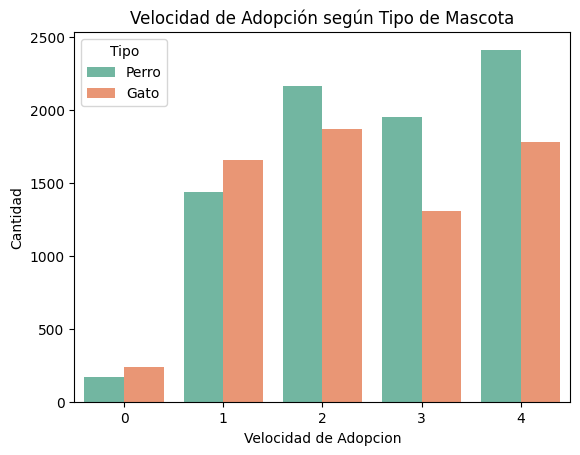

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=dataset, x="AdoptionSpeed", hue="Type", palette="Set2")

plt.title("Velocidad de Adopción según Tipo de Mascota")
plt.xlabel("Velocidad de Adopcion")
plt.ylabel("Cantidad")

plt.legend(title="Tipo", labels=["Perro", "Gato"])

plt.show()

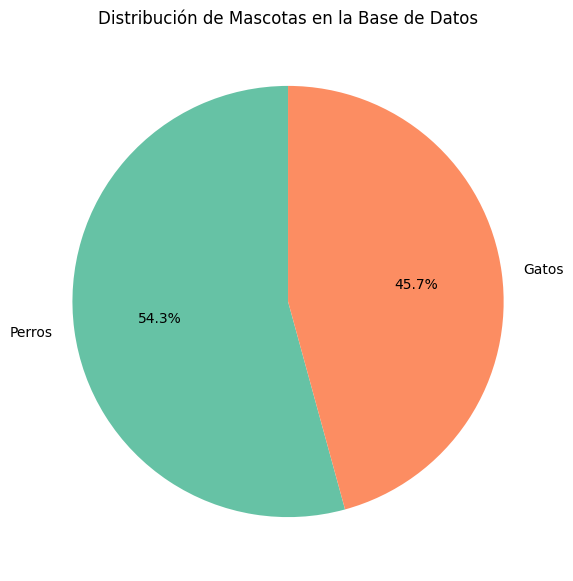

In [ ]:
import matplotlib.pyplot as plt

# Contar perros y gatos
conteo = dataset["Type"].value_counts()
# Etiquetas
labels = ["Perros", "Gatos"]
# Gráfico de torta
plt.figure(figsize=(7,7))
plt.pie(conteo, labels=labels, autopct='%1.1f%%', startangle=90, colors=["#66c2a5", "#fc8d62"])

plt.title("Distribución de Mascotas en la Base de Datos")
plt.show()

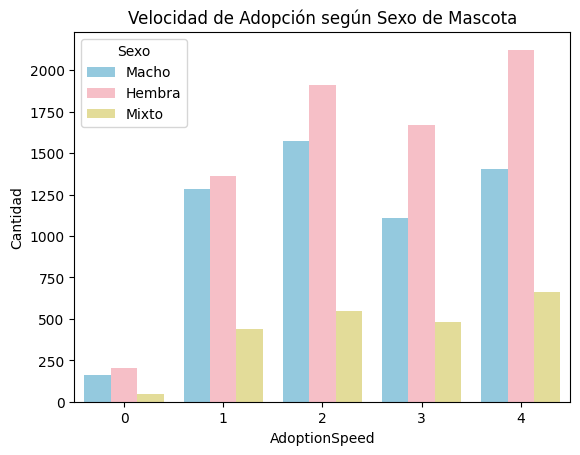

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
colores = ["skyblue", "lightpink", "khaki"]
sns.countplot(
    data=dataset,
    x="AdoptionSpeed",
    hue="Gender",
    palette=colores
)

plt.title("Velocidad de Adopción según Sexo de Mascota")
plt.xlabel("AdoptionSpeed")
plt.ylabel("Cantidad")
plt.legend(title="Sexo", labels=["Macho", "Hembra", "Mixto"])
plt.show()

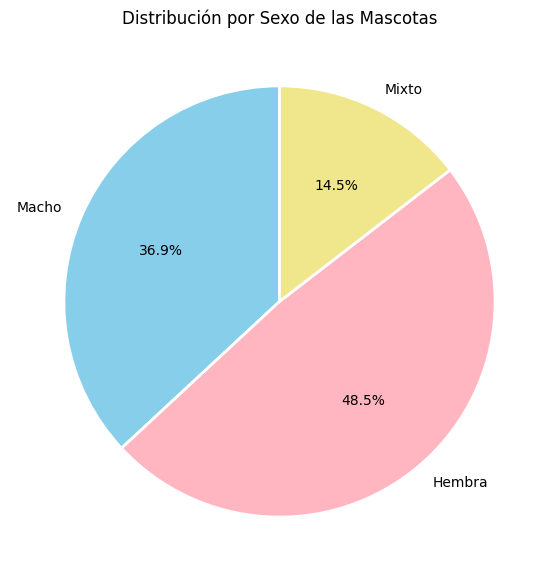

In [ ]:
import matplotlib.pyplot as plt
# Contar Macho (1), Hembra (2) y Mixto (3)
sexo = dataset["Gender"].value_counts().sort_index()
# Etiquetas
labels = ["Macho", "Hembra", "Mixto"]
colores = ["skyblue", "lightpink", "khaki"]

# Gráfico de torta
plt.figure(figsize=(7,7))
plt.pie(
    sexo,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colores,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

plt.title("Distribución por Sexo de las Mascotas")
plt.show()

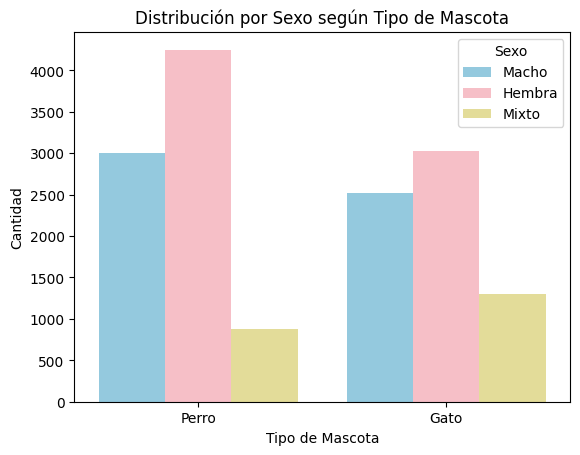

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

colores = ["skyblue", "lightpink", "khaki"]
sns.countplot(
    data=dataset,
    x="Type",
    hue="Gender",
    palette=colores
)
plt.title("Distribución por Sexo según Tipo de Mascota")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Cantidad")
plt.xticks([0,1], ["Perro", "Gato"])
plt.legend(title="Sexo", labels=["Macho", "Hembra", "Mixto"])

plt.show()

# 7 ANALISIS INDIVIDUAL DE VARIABLES


# 7.1 ANALISIS DE VARIABLES POR MALENA RENÉE

**Variables descriptivas de la mascota: Type, Name, Age, Breed1, Breed2, Gender, Color1, Color2, Color3, MaturitySize, FurLength**

*Describen características físicas y generales del animal.*

* ¿Influye el nombre?

* Tamaño & Velocidad de Adopcion

* Pelaje & Velicidad de Adopcion

##7.1.1. Exploracion por nombre de mascota

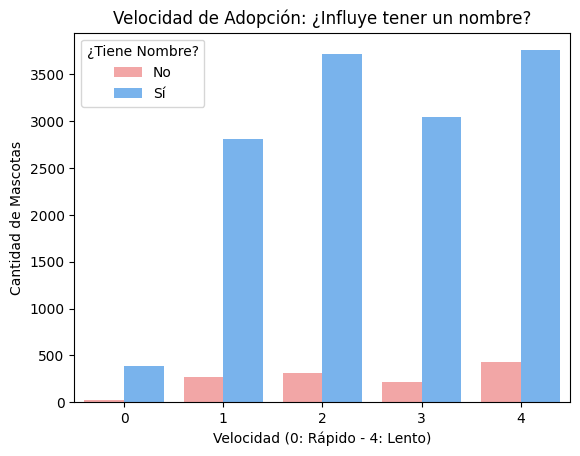

In [ ]:
colores = ["#ff9999", "#66b3ff"] # Colores personalizados
dataset["HasName"] = dataset["Name"].notnull().astype(int)
sns.countplot(
    data = dataset,
    x="AdoptionSpeed",
    hue="Name",
    palette=colores
)

plt.title("Velocidad de Adopción: ¿Influye tener un nombre?")
plt.xlabel("Velocidad (0: Rápido - 4: Lento)")
plt.ylabel("Cantidad de Mascotas")
# Corregimos la leyenda para que coincida con HasName
plt.legend(title="¿Tiene Nombre?", labels=["No", "Sí"])
plt.show()

##7.1.2. Exploración de Atributos Físicos (MaturitySize, FurLength)



 Análisis de Atributos Físicos y Velocidad de Adopción
A partir de los gráficos de barras, podemos observar lo siguiente:

1. Tamaño al madurar (MaturitySize)
Preferencia por el Tamaño Mediano: La mayoría de las mascotas en el dataset son de tamaño 2 (Mediano).

    Notamos que para todos los tamaños, la barra más alta suele ser la 4 (No adoptado después de 100 días). Esto indica que el dataset contiene clases desbalanceadas; hay muchas mascotas que tardan mucho en ser adoptadas, especialmente las medianas.

2. Largo del Pelaje (FurLength)
Pelo Corto domina: Las mascotas de pelo corto (Clase 1) son las más numerosas.

Al igual que con el tamaño, la velocidad de adopción parece seguir una distribución similar independientemente del largo del pelo, lo que sugiere que esta variable por sí sola podría no ser el factor decisivo único.

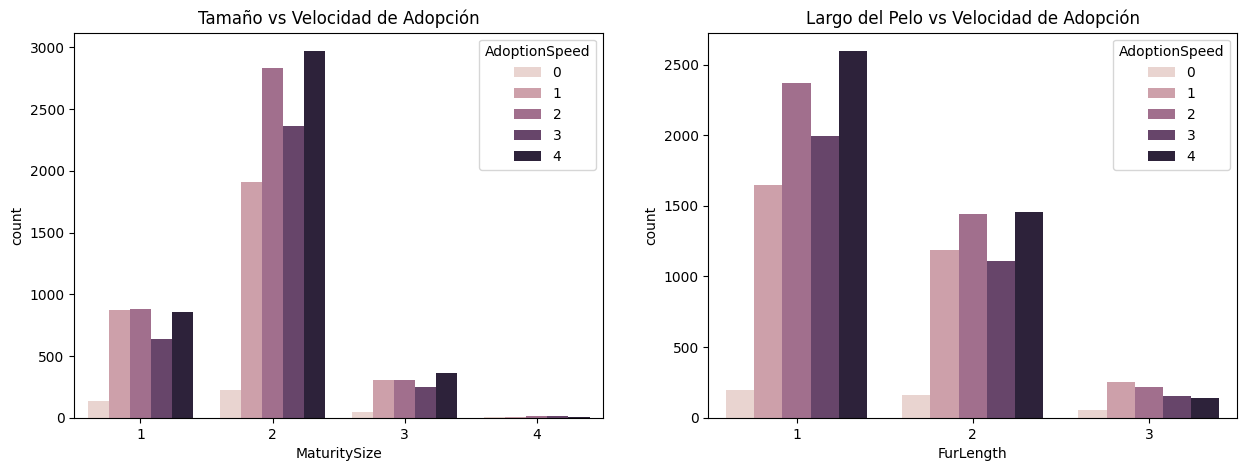

In [ ]:
# Gráfico de barras cruzado con la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tamaño al madurar
sns.countplot(data=dataset, x="MaturitySize", hue="AdoptionSpeed", ax=axes[0])
axes[0].set_title("Tamaño vs Velocidad de Adopción")

# Largo del pelaje
sns.countplot(data=dataset, x="FurLength", hue="AdoptionSpeed", ax=axes[1])
axes[1].set_title("Largo del Pelo vs Velocidad de Adopción")

plt.show()

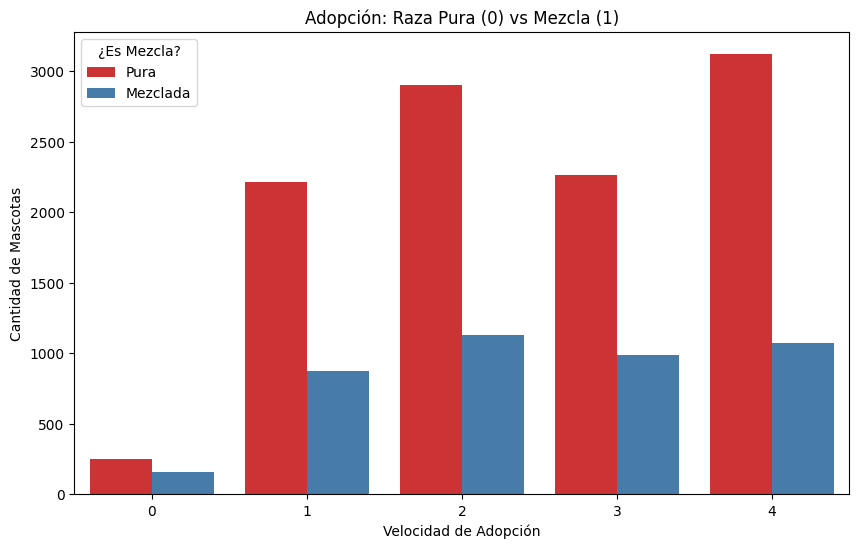

In [ ]:
# Creamos una columna temporal para identificar mezclas
dataset['IsMixed'] = dataset['Breed2'].apply(lambda x: 1 if x > 0 else 0)

# Graficamos la distribución
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x="AdoptionSpeed", hue="IsMixed", palette="Set1")

plt.title("Adopción: Raza Pura (0) vs Mezcla (1)")
plt.xlabel("Velocidad de Adopción")
plt.ylabel("Cantidad de Mascotas")
plt.legend(title="¿Es Mezcla?", labels=["Pura", "Mezclada"])
plt.show()

Predomina una cantidad masiva de animales etiquetados como "Raza Pura" (columna roja) en comparación con los mezclados (azul).
Las barras rojas son altísimas. Esto nos dice que, aunque sean de raza pura, hay muchísimos que no se adoptan rápido.
Si comparamos la Clase 0 (adopción inmediata) con la Clase 4, vemos diferencia de tamaño entre la barra roja y la azul es similar. Esto sugiere que, aunque hay más animales de raza pura en total, no necesariamente se adoptan mucho más rápido que los mezclados.

A pesar de que hay una gran oferta de mascotas de raza pura, sufren largos tiempos de espera para ser adoptados, lo que indica que la raza por si sola no garantiza una adopcción inmediata.

##7.1.3. Analisis de colores

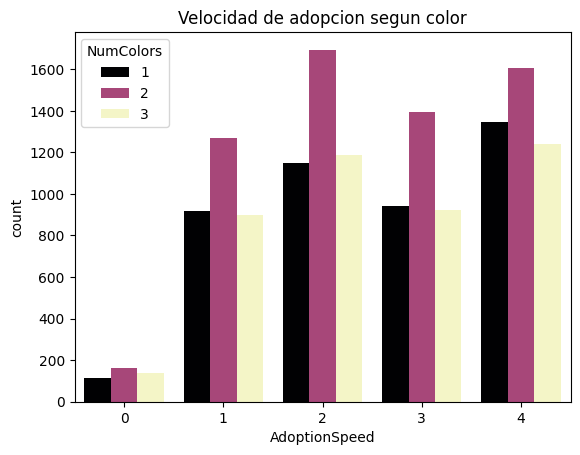

In [ ]:
# Si Color2 es 0, tiene 1 color. Si Color3 es 0 pero Color2 no, tiene 2.
dataset['NumColors'] = dataset.apply(lambda x: 1 + (x['Color2'] > 0) + (x['Color3'] > 0), axis=1)

sns.countplot(data=dataset, x="AdoptionSpeed", hue="NumColors", palette="magma")
plt.title("Velocidad de adopcion segun color")
plt.show()

Las barras tiene casi la misma forma para las mascotas de 1, 2 o 3 colores. Todas suben en la Clase 2 y terminan con un pico en la Clase 4. Podemos concluir que el color no es factor decisivo.


# 7.2 ANALISIS DE VARIABLES POR LUZ MARIA:

**Variables sanitarias y de cuidado: Vaccinated, Dewormed, Sterilized, Health**

*Indican condiciones de salud y tratamientos recibidos.*

* Vacunacion

* Desparacitacion

* Esterilización

* Estado de Salud

## 7.2.1 Visualización de Variables Sanitarias y de Cuidado vs. Velocidad de Adopción

Usaremos gráficos de barras agrupadas (`countplot`) para visualizar cómo las condiciones de vacunación, desparasitación, esterilización y salud se relacionan con la velocidad a la que las mascotas son adoptadas.

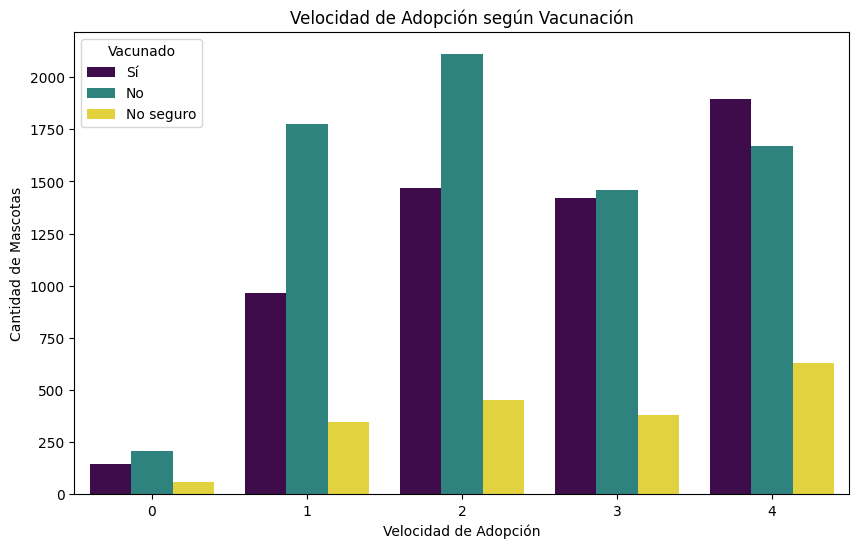

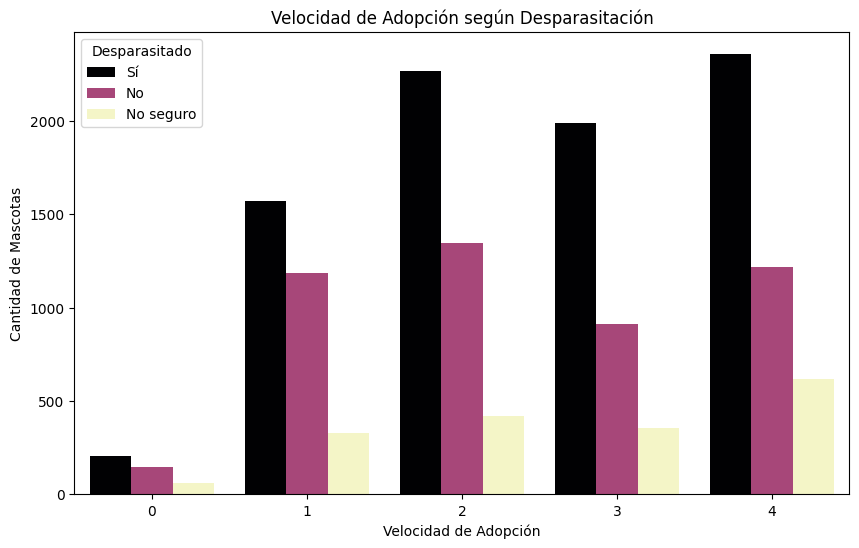

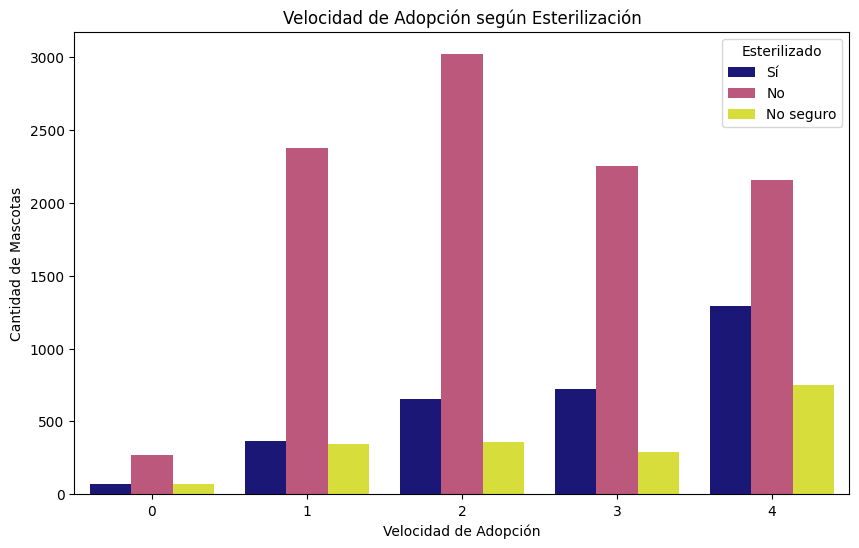

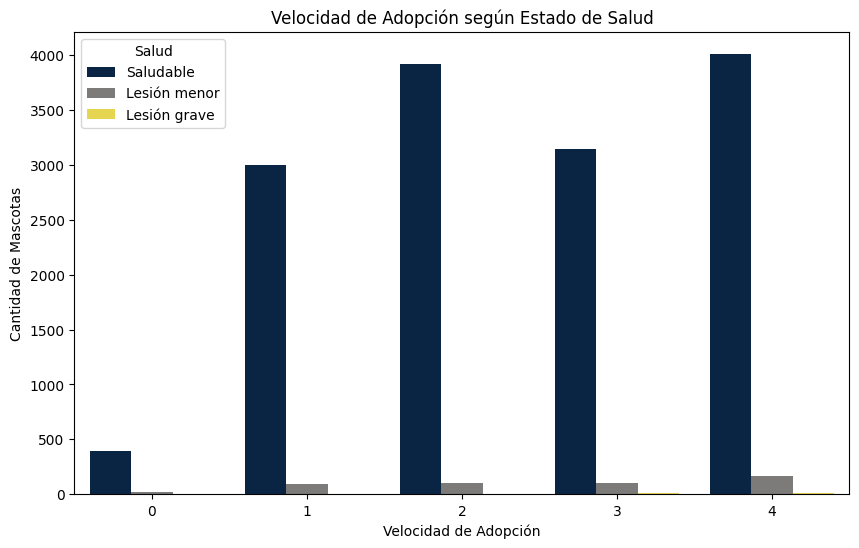

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vaccinated
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x="AdoptionSpeed", hue="Vaccinated", palette="viridis")
plt.title('Velocidad de Adopción según Vacunación')
plt.legend(title='Vacunado', labels=['Sí', 'No', 'No seguro'])
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Cantidad de Mascotas')
plt.show()

# Dewormed
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x="AdoptionSpeed", hue="Dewormed", palette="magma")
plt.title('Velocidad de Adopción según Desparasitación')
plt.legend(title='Desparasitado', labels=['Sí', 'No', 'No seguro'])
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Cantidad de Mascotas')
plt.show()

# Sterilized
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x="AdoptionSpeed", hue="Sterilized", palette="plasma")
plt.title('Velocidad de Adopción según Esterilización')
plt.legend(title='Esterilizado', labels=['Sí', 'No', 'No seguro'])
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Cantidad de Mascotas')
plt.show()

# Health
plt.figure(figsize=(10, 6))
sns.countplot(data=dataset, x="AdoptionSpeed", hue="Health", palette="cividis")
plt.title('Velocidad de Adopción según Estado de Salud')
plt.legend(title='Salud', labels=['Saludable', 'Lesión menor', 'Lesión grave'])
plt.xlabel('Velocidad de Adopción')
plt.ylabel('Cantidad de Mascotas')
plt.show()

### 7.2.2 Conclusiones de las Visualizaciones de Variables Sanitarias y de Cuidado

Basándonos en los gráficos de barras que relacionan las variables sanitarias y de cuidado con la velocidad de adopción (`AdoptionSpeed`), podemos extraer las siguientes conclusiones:


  - En los gráficos de `Vaccinated` y `Dewormed`, se observa  que la proporción de mascotas **'Sí'** (vacunadas o desparasitadas) es mayor en las categorías de `AdoptionSpeed` más bajas (0, 1, 2). Esto sugiere una fuerte preferencia por parte de los adoptantes hacia mascotas que ya cuentan con estas atenciones básicas, acelerando su proceso de adopción.
  

   *   El gráfico de `Health` muestra que las mascotas **'Saludables'** (`1`) dominan notoriamente las categorías de adopción más rápidas. Por el contrario, las mascotas con `Lesión menor` (`2`) o `Lesión grave` (`3`) tienen una presencia mucho mayor en la categoría `AdoptionSpeed = 4` (no adoptadas después de 100 días). Esto indica que cualquier problema de salud, especialmente si es grave,disminuye el proceso de adopción.


  *   Si bien las mascotas **'Esterilizadas'** (`Sí`) también se observan con mayor frecuencia en las categorías de adopción más rápidas en el gráfico de `Sterilized`, la diferencia no es tan marcada como en el caso de la vacunación o el estado de salud. La esterilización parece tener un peso ligeramente menor en la decisión de adopción rápida en comparación con otras variables sanitarias.


AdoptionSpeed    0     1     2     3     4
Vaccinated                                
1              146   963  1470  1419  1894
2              206  1777  2110  1458  1671
3               58   348   452   381   627


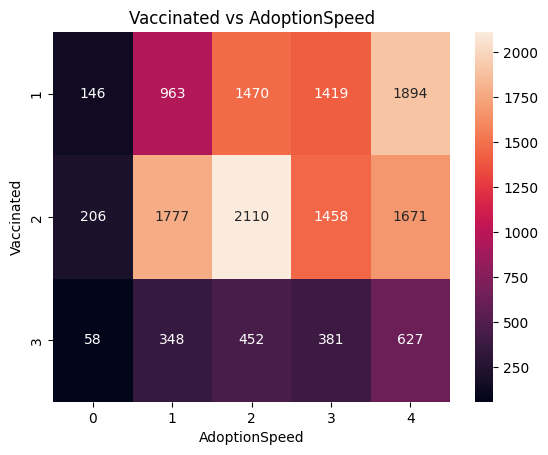

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
tabla = pd.crosstab(dataset["Vaccinated"], dataset["AdoptionSpeed"])
print(tabla)
sns.heatmap(tabla, annot=True, fmt="d")
plt.title("Vaccinated vs AdoptionSpeed")
plt.show()

### 7.3 ANALISIS DE VARIABLES POR ANDREA PAOLA:

**Variables descriptivas de la mascota: Type, Age**

*Describen características físicas y generales del animal.*

* Type & Age

**Variables con informacion: Quantity, Free, Age**

* Quantity

* Free

##7.3.1 Analisis Tipo de mascota según edad (en meses)
El diagrama de cajas muestra que tanto perros como gatos presentan distribuciones de edad similares, concentrándose la mayoría de las observaciones en animales jóvenes. Sin embargo, existen numerosos valores atípicos correspondientes a mascotas de mayor edad, especialmente en perros, donde se observan edades superiores a los 250 meses. Debido a la gran cantidad de outliers, para el análisis posterior se considerará únicamente el rango de 0 a 18 meses, sin modificar el conjunto de datos original.

/tmp/ipykernel_3010/2524583362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x="Type", y="Age", palette="Set2")


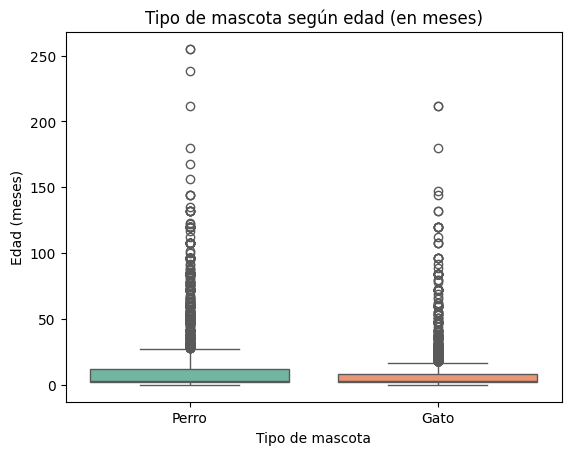

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=dataset, x="Type", y="Age", palette="Set2")
plt.xticks([0,1], ['Perro', 'Gato'])
plt.title("Tipo de mascota según edad (en meses)")
plt.xlabel("Tipo de mascota")
plt.ylabel("Edad (meses)")
plt.show()

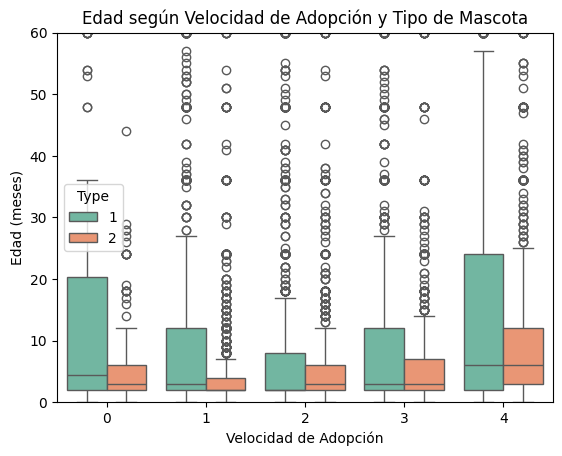

In [ ]:
sns.boxplot(
    data=dataset,
    x="AdoptionSpeed",
    y="Age",
    hue="Type",
    palette="Set2"
)

plt.ylim(0,60)

plt.title("Edad según Velocidad de Adopción y Tipo de Mascota")
plt.xlabel("Velocidad de Adopción")
plt.ylabel("Edad (meses)")
#plt.legend(title="Tipo", labels=["Perro", "Gato"])

plt.show()

## Analisis Edad según velocidad de adopción y tipo de mascota (con todos los datos)

Al relacionar la edad con la velocidad de adopción y el tipo de mascota, se observa una fuerte presencia de valores atípicos que dificultan la interpretación de las distribuciones. En todas las categorías de velocidad predominan animales de baja edad, aunque los perros presentan una mayor dispersión que los gatos. La elevada cantidad de outliers justifica realizar un análisis adicional restringiendo la edad a 18 meses.


Se observan muchos valores atipicos que deben ser filtrados (lo pruebo sin modificar mi DataSet, solo analizo los animales menores a año y medio (18 meses)
**mas adelante en el DataSet se debera eliminar antes de hacer el MODELO PREDICTIVO**

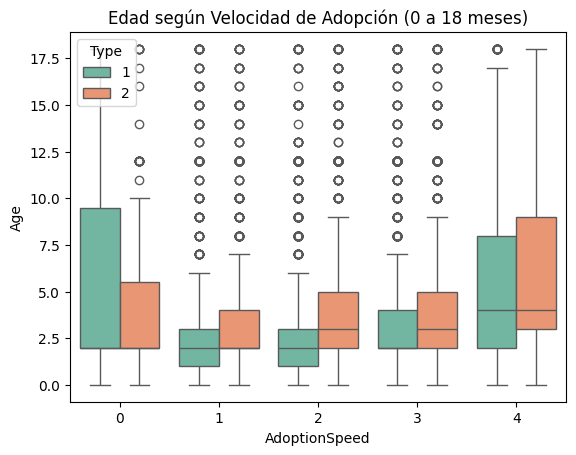

In [ ]:
dataset2 = dataset[dataset["Age"] <= 18]

sns.boxplot(
    data=dataset2,
    x="AdoptionSpeed",
    y="Age",
    hue="Type",
    palette="Set2"
)

plt.title("Edad según Velocidad de Adopción (0 a 18 meses)")
#plt.legend(title="Tipo", labels=["Perro", "Gato"])
plt.show()


## Analisis de Edad según velocidad de adopción (0 a 18 meses)

Al limitar el análisis a mascotas de hasta 18 meses, las distribuciones se observan con mayor claridad. En general, las edades más bajas concentran la mayor cantidad de adopciones en todas las categorías de velocidad. Se aprecia además una leve tendencia a que las mascotas con mayor edad presenten velocidades de adopción más altas (categorías 3 y 4), aunque la diferencia entre perros y gatos no resulta muy marcada dentro de este rango.

## 7.3.2 Cantidad de mascotas en la publicacion de adopcion

/tmp/ipykernel_3010/1867841561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


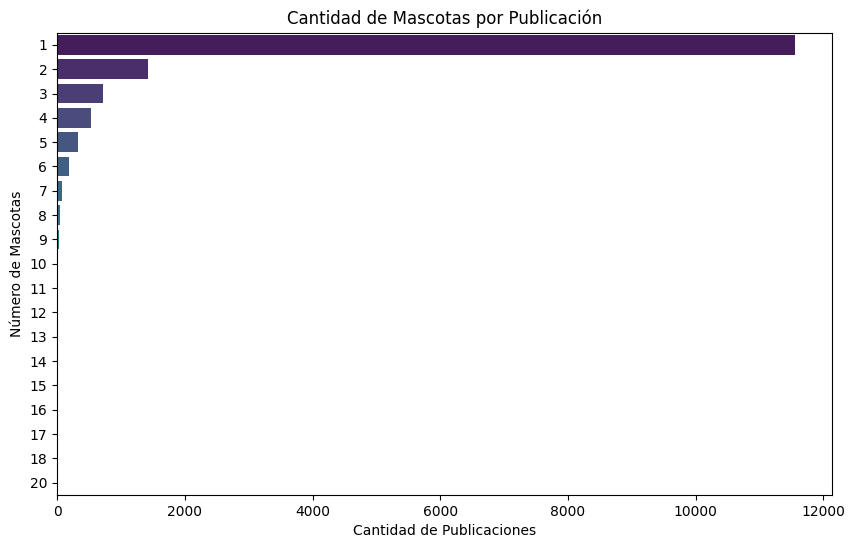

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=dataset,
    y="Quantity",
    palette="viridis"
)

plt.title("Cantidad de Mascotas por Publicación")
plt.xlabel("Cantidad de Publicaciones")
plt.ylabel("Número de Mascotas")

plt.show()

##Analisis Cantidad de mascotas por publicación

La distribución evidencia un marcado desbalance en la variable Quantity. La gran mayoría de las publicaciones corresponde a una sola mascota, mientras que las publicaciones con dos o más animales disminuyen progresivamente hasta representar una proporción muy pequeña del total. Esto indica que las publicaciones múltiples son poco frecuentes en el conjunto de datos.

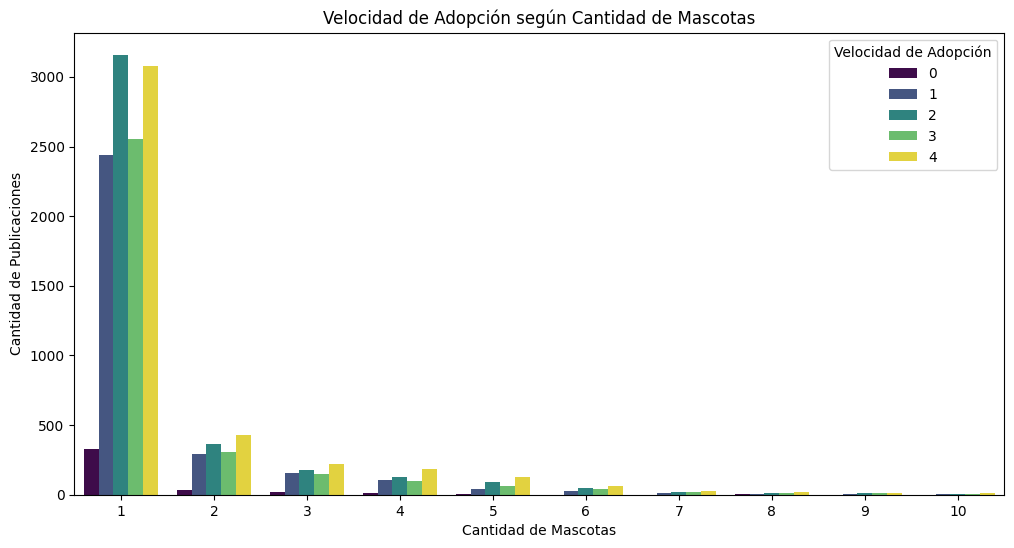

In [ ]:
# Filtrar cantidades de 1 a 10
dataset_filtrado = dataset[dataset["Quantity"] <= 10]

plt.figure(figsize=(12,6))

sns.countplot(
    data=dataset_filtrado,
    x="Quantity",
    hue="AdoptionSpeed",
    palette="viridis"
)

plt.title("Velocidad de Adopción según Cantidad de Mascotas")
plt.xlabel("Cantidad de Mascotas")
plt.ylabel("Cantidad de Publicaciones")

plt.legend(title="Velocidad de Adopción")
plt.show()

In [ ]:
dataset["Quantity"].value_counts().sort_index()

,count
Quantity,
1,11556
2,1419
3,726
4,530
5,333
6,185
7,84
8,52
9,33


##Analisis Velocidad de adopción según cantidad de mascotas

Se observa que las publicaciones de una sola mascota predominan en todas las categorías de velocidad de adopción. A medida que aumenta la cantidad de mascotas por publicación, el número de casos disminuye considerablemente. No se identifica una relación clara entre la cantidad de mascotas publicadas y la velocidad de adopción, ya que el patrón de distribución es similar en las distintas categorías y la diferencia principal corresponde al desbalance de la variable Quantity.

En PetFinder la mayoría de publicaciones tienen: Quantity = 1, pero algunas tienen valores altos (camadas),
* las publicaciones con muchos animales suelen adoptarse distinto,
* puede relacionarse con AdoptionSpeed,
* puede indicar rescates o refugios.

A futuro podemos en vez de usar los numeros exactos agrupar: por Individual, Pequeño grupo, Camada/grupo grande

##7.3.3 Analisis Distribucion del costo de Adopcion
La gráfica muestra la distribución del costo de adopción entre perros y gatos utilizando un violinplot. En ambos casos, la mayor concentración de valores se encuentra en costos bajos o cercanos a cero, lo que indica que la mayoría de las mascotas son ofrecidas con tarifas de adopción económicas o gratuitas.

También se observan valores extremos (outliers), especialmente en los perros, donde existen publicaciones con costos considerablemente más altos que en los gatos. Esto provoca una distribución más dispersa y una cola superior mucho más larga en los perros.

En comparación, los gatos presentan una distribución más compacta y con menor variabilidad en los costos de adopción.

/tmp/ipykernel_3010/501041852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


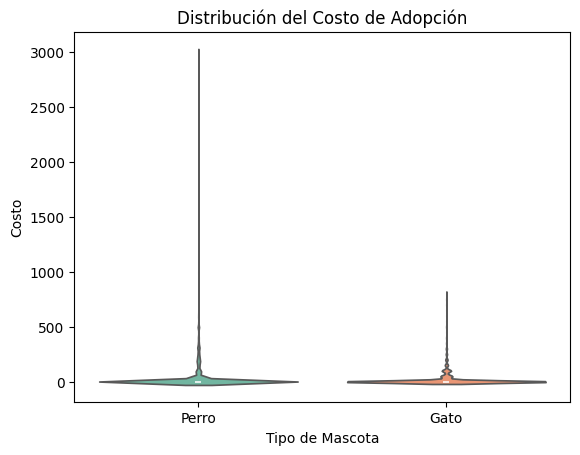

In [ ]:
#Costo de Adopcion "Free"
sns.violinplot(
    data=dataset,
    x="Type", y="Fee",
    palette="Set2"
)

plt.title("Distribución del Costo de Adopción")
plt.xlabel("Tipo de Mascota")
plt.ylabel("Costo")

plt.xticks([0,1], ["Perro", "Gato"])
plt.show()

##7.3.4 Analisis Distribucion de Adopcion en Estados o Regiones
El estado Selangor (41326) concentra la mayor cantidad de mascotas en todas las velocidades de adopción, seguido por Kuala Lumpur (41401). Los demás estados presentan una participación significativamente menor, evidenciando que la mayor parte de las adopciones se concentra en pocos estados.


Para nuestro EDA nos sirve para una exploracion más visual, pero no vemos que sea necesariamente usarlo en la matriz de correlación.


In [ ]:
estados = dataset["State"].value_counts().reset_index()

estados.columns = ["Estado", "Cantidad de Publicaciones"]

print(estados)

    Estado  Cantidad de Publicaciones
0    41326                       8707
1    41401                       3840
2    41327                        843
3    41336                        507
4    41330                        419
5    41332                        253
6    41324                        137
7    41325                        110
8    41335                         85
9    41361                         26
10   41345                         22
11   41367                         15
12   41342                         13
13   41415                          3


| Código | Estado                | Cantidad                |
| ------ | --------------------- | --------------------- |
| 41326  | Selangor              |    8707|
| 41401  | Kuala Lumpur          |3840|
| 41327  | Pulau Pinang (Penang) |843|
| 41336  | Johor                 |507|
| 41330  | Perak                 |419|
| 41332  | Sabah                 |253|
| 41324  | Kedah                 |137|
| 41325  | Kelantan              |110|
| 41335  | Negeri Sembilan       |85|
| 41361  | Sarawak               |26|
| 41345  | Melaka                |22|
| 41367  | Terengganu            |15|
| 41342  | Pahang                |13|
| 41415  | Labuan                |3|


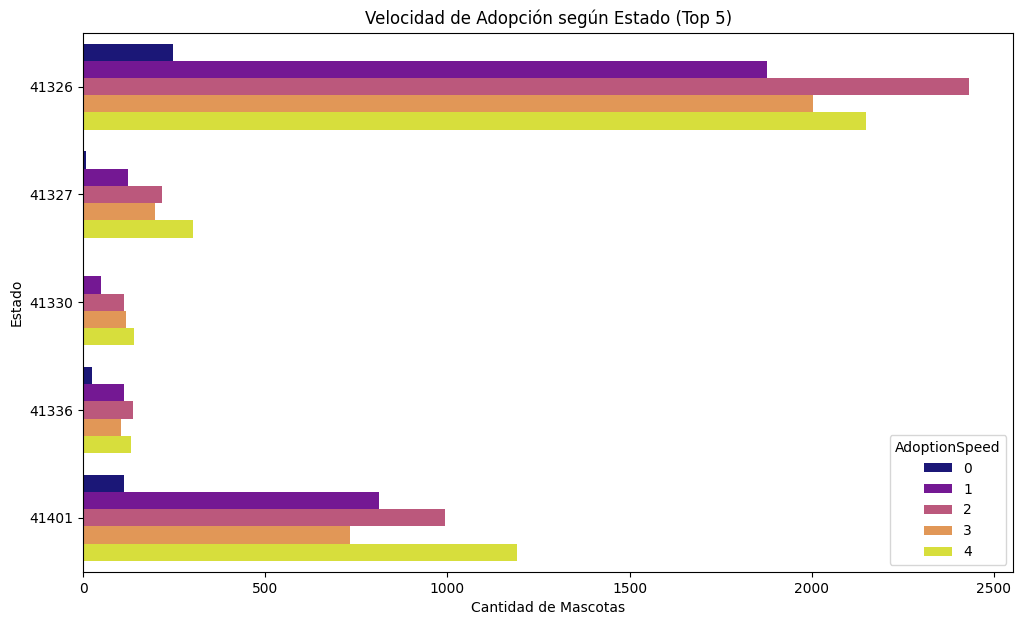

In [ ]:
# Top 5 estados con más publicaciones en malasia (por codigo de estado)

top_estados = dataset["State"].value_counts().head(5).index

dataset_top = dataset[dataset["State"].isin(top_estados)]
plt.figure(figsize=(12,7))
sns.countplot(
    data=dataset_top,
    y="State",
    hue="AdoptionSpeed",
    palette="plasma"
)

plt.title("Velocidad de Adopción según Estado (Top 5)")
plt.xlabel("Cantidad de Mascotas")
plt.ylabel("Estado")

plt.show()

##8. EDA: ANALIZANDO LAS VARIBALES DECIDIMOS OPTAR POR:

##OBVIAR LAS VARIABLES:
* **Gender**	Entero	Sexo (1 = Macho, 2 = Hembra, 3 = Mixto)
DEBATIENDO DE SOLO TRABAJAR CON MACHOS/HEMBRAS, para ello deberiamos obviar el genero MIXTO, entonces si reemplazamos por un promedio para que quede equitativo entonces, de tener 36,9% MACHOS 48,5% HEMBRA Y 14.5% MIXTO quedaria incrementedo en 7,25% LOS MACHOS Y 7,25% LAS HEMBRAS, no optando or las moda "HEMBRAS" ya que quedaria muy desbalanceado. PERO ESTO SERIA "INVENTAR" UN DATO, Y YA QUE AL MODELO NO LE INFLUYE EL GENERERO DEL ANIMAL POR LO QUE VIMOS EN EL GRAFICO DE BARRAS COMPARANDO GENDER CON ADOPTIONSPEDD ES SIMILAR, NO HAY MUCHA DIFERENCIA ENTRE MACHOS / HEMBRAS / MIXTO, POR ELLO CONCLUIMOS EN SACAR ESTA VARIABLE DE NUESTRO ANALISIS.

* **Color1**	Entero	Color principal (código)
* **Color2**	Entero	Color secundario
* **Color3**	Entero	Tercer color
* **VideoAmt**	Entero	Cantidad de videos
* **Description**	Texto	Descripción de la mascota
* **PetID**	Texto	ID único de la mascota
* **RescuerID**	Texto	ID del rescatista/publicador
* **PhotoAmt**	Decimal	Cantidad de fotos
* **MaturitySize**	Entero	Tamaño estimado adulto (1 = Pequeño, 2 = Mediano, 3 = Grande, 4 = Extra grande, 0 = Desconocido)
* **FurLength**	Entero	Largo del pelaje (1 = Corto, 2 = Medio, 3 = Largo, 0 = Desconocido)
* **Fee**	Entero	Costo de adopción
* **State**	Entero	Estado/región de Malasia (código)



HACER TABLA PARA VER TAMAÑO DE PROPORCIONES DE **MaturitySize** Y **FurLength**

##CATEGORIZAR LAS VARIABLES:

* **Age**	(Al tener valores extremos que no sabemos si son reales o errores de tipero la categorizaremos en Cachorro, Joven, Adulto tomando en cuenta el promedio 11 MESES APOX  CACHORRO DE 0-5 MESES JOVEN DE 5-12 ADULTO 12 EN ADELANTE)
* **Quantity**	Entero	Cantidad de mascotas en la publicación (individual 1 mascota/ grupo pequeño 2-4 / grupo grande 4 en adelante)

##APLICAR ONE HOT SOBRE:
* **Type**	Entero	Tipo de mascota (1 = Perro, 2 = Gato)

## VARIABLES QUE NO CAMBIAMOS:
* **Name**	(ya se modifico previamente por 0 sin nombre 1 con nombre)
* **Vaccinated**	Entero	Vacunado (1 = Sí, 2 = No, 3 = No seguro)
* **Dewormed**	Entero	Desparasitado (1 = Sí, 2 = No, 3 = No seguro)
* **Health**	Entero	Estado de salud (1 = Saludable, 2 = Lesión menor, 3 = Lesión grave, 0 = Desconocido)


## PENDIENTE
DEBATE SI SE CAMBIA A 0/1 CON RAZA O MESTIZO Y APLICO ONE HOT O SE SACA DEL DATASET
* **Breed1**	Entero	Raza principal (código)
* **Breed2**	Entero	Raza secundaria (0 = ninguna)
DEBATE
* **Sterilized**	Entero	Esterilizado/Castrado (1 = Sí, 2 = No, 3 = No seguro)
YA QUE SON ADOPTADOS EN EDAD QUE AUN NO ESTAN APTOS PARA CASTRAR
Y TAMBIEN INFLUYE SI ES DE RAZA O NO AL MOMENTO DE QUE NO ESTARIA CASTRADO

## VARIABLE PREDICTIVA
* **AdoptionSpeed**	Entero	Variable objetivo: velocidad de adopción



In [ ]:
tabla_tamano = (dataset["MaturitySize"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

print(tabla_tamano)

MaturitySize
1    22.64
2    68.75
3     8.38
4     0.22
Name: proportion, dtype: float64


In [ ]:
tabla_pelaje = (
    dataset["FurLength"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

print(tabla_pelaje)

FurLength
1    58.74
2    35.76
3     5.49
Name: proportion, dtype: float64


##8.1 Conclusiones de las tablas de proporción para maturitysize y fur

Al analizar dichas tablas, observamos una distribución muy sesgada: la gran mayoría de las mascotas denotadas en la base de datos son de tamaño mediano (clase 2 de 'maturitysize') y de pelo corto (clase 1 de 'fur'), en contraposición con los demás datos de las variables.

 Esto significa que los datos están desproporcionados o no son uniformes, y que la mayoría de los mismos se concentran en una o dos categorías, lo que podría dificultar a la hora de armar el modelo de machine learning. Un modelo podría volverse sesgado o generalizar demasiado, cosa que a futuro puede contribuir al overfitting.

 Por lo tanto, se tomó la desición de obviar dichas variables.

In [ ]:
##NUEVO DATASET
dataset2 = dataset.copy()

##Ignoramos las Variables: Gender / Color1 / Color2 / Color3 / VideoAmt / Description/ PetID / RescuerID / PhotoAmt / MaturitySize / FurLength / Fee/ State
columns_to_drop_1 = [
    "Gender", "Color1", "Color2", "Color3", "VideoAmt", "Description",
    "PetID", "RescuerID", "PhotoAmt", "MaturitySize", "FurLength", "Fee", "State"
]
# Drop these columns from the dataset2. Use errors='ignore' to avoid KeyError if any column is already missing.
dataset2 = dataset2.drop(columns=columns_to_drop_1, errors='ignore')

##Ignoramos las Variables creadas para el analisis: HasName / IsMixed / NumColors
columns_to_drop_2 = ["HasName", "IsMixed", "NumColors"]

# Drop these additional columns from the already modified dataset2. Use errors='ignore'.
dataset2 = dataset2.drop(columns=columns_to_drop_2, errors='ignore')

#Categorizamos la Variables:

#Age: Categorizada según meses
#____1)Cachorro:	0–12
#____2)Joven:	12–60
#____3)Adulto:	60+

edad = [0, 12, 60, dataset2["Age"].max() + 1]

dataset2["Age"] = pd.cut(
    dataset2["Age"],
    bins=edad,
    labels=[1, 2, 3],
    right=False
).astype(int)

#Quantity: Categorizada segun cantidad de mascotas
#____1)Individual:	1 mascota
#____2)Grupo Pequeño:	2 a 4 mascotas
#____3)Grupo Grande:	5 o más

grupo=[0, 2, 5, dataset2["Quantity"].max() + 1]

dataset2["Quantity"] = pd.cut(
    dataset2["Quantity"],
    bins=grupo,
    labels=[1, 2, 3],
    right=False
).astype(int)

# Breed:Categorizada segun mascotas con o sin raza
#____1)Tiene Raza:	1
#____2)No es de Raza:	0

# Create the 'Breed' column from 'Breed2' which should still be in dataset2 at this point.
dataset2["Breed"] = (dataset2["Breed2"] != 0).astype(int)
# Now drop the original 'Breed1' and 'Breed2' columns from dataset2.
dataset2 = dataset2.drop(columns=["Breed1", "Breed2"], errors='ignore')

# Mostrar primeras filas del nuevo dataset2
dataset2.head()

,Type,Name,Age,Vaccinated,Dewormed,Sterilized,Health,Quantity,AdoptionSpeed,Breed
0,2,1,1,2,2,2,1,1,2,0
1,2,1,1,3,3,3,1,1,0,0
2,1,1,1,1,1,2,1,1,3,0
3,1,1,1,1,1,2,1,1,2,0
4,1,1,1,2,2,2,1,1,2,0


In [ ]:
#Informacion de Variables
dataset2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14980 entries, 0 to 14992
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Type           14980 non-null  int64
 1   Name           14980 non-null  int64
 2   Age            14980 non-null  int64
 3   Vaccinated     14980 non-null  int64
 4   Dewormed       14980 non-null  int64
 5   Sterilized     14980 non-null  int64
 6   Health         14980 non-null  int64
 7   Quantity       14980 non-null  int64
 8   AdoptionSpeed  14980 non-null  int64
 9   Breed          14980 non-null  int64
dtypes: int64(10)
memory usage: 1.3 MB


#9. MATRIZ DE CORRELACION



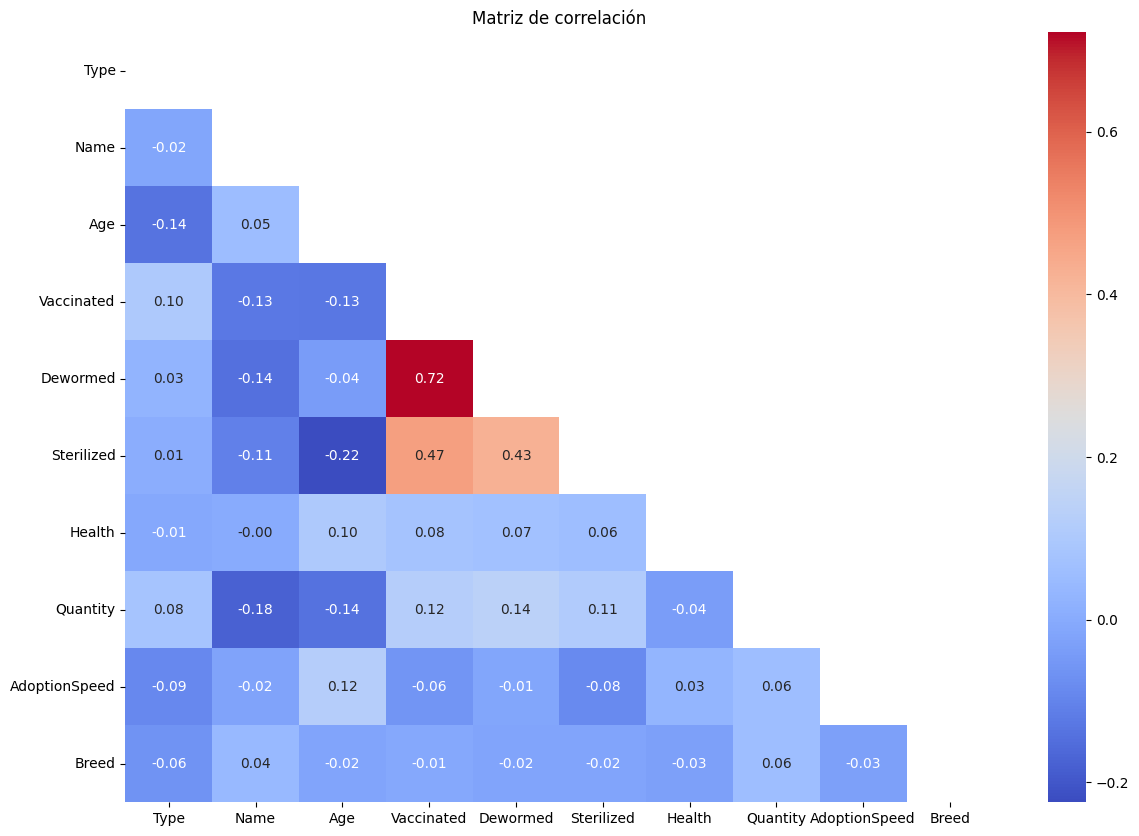

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = dataset2.corr(numeric_only=True)
mascara = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14,10))

sns.heatmap(
    corr, mask=mascara,
    annot=True, cmap="coolwarm",
    fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

## Analisis de Matriz de correlación:

La matriz de correlación evidencia que la mayoría de las variables presentan correlaciones bajas, lo que indica una escasa relación lineal entre ellas. Esto sugiere que cada variable aporta información diferente al conjunto de datos y que no existe un problema importante de multicolinealidad.

La relación más significativa se observa entre Vaccinated y Dewormed (r = 0,72), indicando que los animales vacunados también tienden a estar desparasitados. Además, Sterilized presenta una correlación positiva moderada con Vaccinated (r = 0,47) y Dewormed (r = 0,43), lo que refleja que estas prácticas de cuidado suelen estar asociadas.

Respecto de la variable objetivo AdoptionSpeed, las correlaciones con el resto de las variables son muy bajas (|r| < 0,12), lo que sugiere que la velocidad de adopción no depende de una única característica de forma lineal, sino probablemente de la combinación de múltiples factores.

| Variables               | Correlación | Interpretación                                                 |
| ----------------------- | ----------- | -------------------------------------------------------------- |
| Vaccinated ↔ Dewormed   | 0.72        | Muy fuerte: las mascotas vacunadas suelen estar desparasitadas |
| Vaccinated ↔ Sterilized | 0.47        | Moderada: suele hacerse junto                                  |
| Dewormed ↔ Sterilized   | 0.43        | Moderada                                                       |
| Age ↔ Breed1            | -0.30       | Relación moderada negativa                                     |
| AdoptionSpeed ↔ Age     | 0.12        | Muy débil                                                      |
| AdoptionSpeed ↔ Breed1  | 0.11        | Muy débil                                                      |

Sobre `AdoptionSpeed`:
* ninguna variable supera ±0.2,
* la adopción depende de múltiples factores combinados,

#10. ONE HOT
One-Hot Encoding es una técnica de preprocesamiento que transforma las variables categóricas en variables binarias (0 y 1), permitiendo que puedan ser utilizadas por algoritmos de aprendizaje automático. Aplicamos sobre la variable **Type (Perro= 1 Gato=2)**

In [ ]:
import pandas as pd

dataset2 = pd.get_dummies(dataset2, columns=["Type"], dtype=int)
display(dataset2.head())


,Name,Age,Vaccinated,Dewormed,Sterilized,Health,Quantity,AdoptionSpeed,Breed,Type_1,Type_2
0,1,1,2,2,2,1,1,2,0,0,1
1,1,1,3,3,3,1,1,0,0,0,1
2,1,1,1,1,2,1,1,3,0,1,0
3,1,1,1,1,2,1,1,2,0,1,0
4,1,1,2,2,2,1,1,2,0,1,0


In [ ]:
#Informacion de Variables

dataset2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 14980 entries, 0 to 14992
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Name           14980 non-null  int64
 1   Age            14980 non-null  int64
 2   Vaccinated     14980 non-null  int64
 3   Dewormed       14980 non-null  int64
 4   Sterilized     14980 non-null  int64
 5   Health         14980 non-null  int64
 6   Quantity       14980 non-null  int64
 7   AdoptionSpeed  14980 non-null  int64
 8   Breed          14980 non-null  int64
 9   Type_1         14980 non-null  int64
 10  Type_2         14980 non-null  int64
dtypes: int64(11)
memory usage: 1.4 MB


In [ ]:
# Guardado del nuevo archivo para aplicar los modelos predictivos
contentFolder = "/content/drive/MyDrive/PETFINDER"
preprocessed_path = f"{contentFolder}/train_eda.csv"
dataset2.to_csv(preprocessed_path)

print(f"Archivo preprocesado guardado en: {preprocessed_path}")


Archivo preprocesado guardado en: /content/drive/MyDrive/PETFINDER/train_eda.csv


## Continuamos trabajando indivivualmente ejecutandon RANDOM FOREST / GRADIENT BOOSTING / XGBOOST